In [125]:
%run helperFunctions.ipynb

read: ./data/faulty\Circuit_Scenario1_batery_1_broken_res.csv
read: ./data/faulty\Circuit_Scenario1_switch1_broken_res.csv
read: ./data/faulty\Circuit_Scenario2_battery2_broken_res.csv
read: ./data/faulty\Circuit_Scenario2_battery2_empty_res.csv
read: ./data/faulty\Circuit_Scenario2_switch_2_broken_res.csv
read: ./data/faulty\Circuit_Scenario3_battery_1_empty_res.csv
read: ./data/faulty\Circuit_Scenario3_switch_1_broken_res.csv
read: ./data/faulty\Circuit_Scenario4_battery_1_broken_res.csv
read: ./data/faulty\Circuit_Scenario4_battery_1_empty_res.csv
read: ./data/faulty\Circuit_Scenario4_switch_1_broken_res.csv
read: ./data/faultless\Circuit_Scenario1_res.csv
read: ./data/faultless\Circuit_Scenario2_res.csv
read: ./data/faultless\Circuit_Scenario3_res.csv
read: ./data/faultless\Circuit_Scenario4_res.csv


In [28]:
def build_float_to_boolean_encoder():
    # 1) Input layer for two float inputs
    input_layer = tf.keras.Input(shape=(2,), name="float_input")  # Shape (batch_size, 2)

    # Create a normalization layer
    norm = layers.Normalization(axis=-1)
   
    x = norm(input_layer)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.1)(x) 
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.1)(x)  # 20% dropout for regularization
    x = layers.Dense(16, activation='relu')(x)
    x = layers.Dropout(0.1)(x)  # another dropout
    x = layers.Dense(8, activation='relu')(x)
    x = layers.Dropout(0.1)(x) 

    outputs = layers.Dense(3, activation='sigmoid')(x)

    model = Model(inputs=input_layer, outputs=outputs)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        #metrics=['accuracy']  
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='binary_accuracy'),
            tf.keras.metrics.AUC(name='auc')
        ]
        # Tracks the accuracy of individual bits (0/1)
    )

    # Return both the model and the normalization layer (we'll adapt it later)
    return model, norm



In [29]:
def train(): 
    model, norm_layer = build_float_to_boolean_encoder()
    df = getTrainingDataResistance()
    y = df[["circ1.s[1].mode", "circ1.s[2].mode", "circ1.s[3].mode"]].astype(float).values
    # Convert output column to float as well:
    X = df[["circ1.r_load.v", "circ1.r_load.r_int"]].astype(float).values
    Y_binary = y - 1.0
        # We must "adapt" the normalization layer on our training data
    norm_layer.adapt(X)
    
        # Print a summary
    model.summary()
    
        # Train/fit the model
    history = model.fit(
        X, 
        Y_binary, 
        epochs=10,        # Feel free to increase epochs
        batch_size=4,
        verbose=1
    )
    
        # Optional: Plot the training loss over epochs
    plt.plot(history.history['loss'], label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs')
    plt.legend()
    plt.show()
    return model, norm_layer
   

read: ./data/training/Circuit_ScenarioDataGeneration_Restistance_res.csv
Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 float_input (InputLayer)    [(None, 2)]               0         
                                                                 
 normalization_2 (Normalizat  (None, 2)                5         
 ion)                                                            
                                                                 
 dense_10 (Dense)            (None, 64)                192       
                                                                 
 dropout_8 (Dropout)         (None, 64)                0         
                                                                 
 dense_11 (Dense)            (None, 32)                2080      
                                                                 
 dropout_9 (Dropout)         (None, 32)             

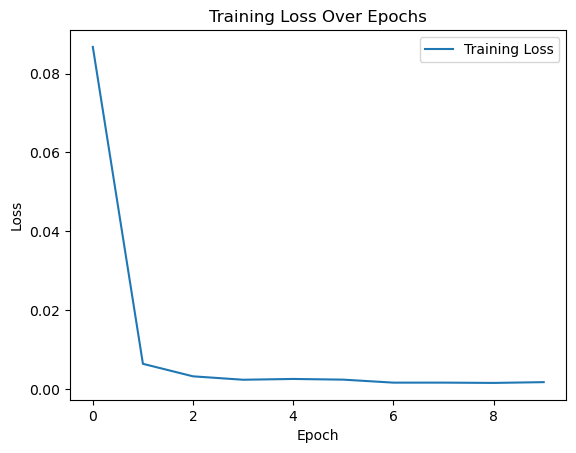

In [30]:
model, norm_layer = train()

In [137]:
def test(model, norm_layer): 
    #wtf why does mixed data behave differently 
    df = getFaultyData()
    #df = getFaultlessData()
   # df = df_f.append(df_l)
    #df = getMixedData()
   # print(f"X shape: {df_f.shape}, y shape: {df_l.shape}, y shape: {df.shape}")
    #df = df_old.drop_duplicates(subset=["circ1.r_load.v", "circ1.r_load.r_int", 
         #                        "circ1.s[1].mode", "circ1.s[2].mode", "circ1.s[3].mode"])
    y = df[["circ1.s[1].mode", "circ1.s[2].mode", "circ1.s[3].mode"]].astype(float).values
    # Convert output column to float as well:
    X = df[["circ1.r_load.v", "circ1.r_load.r_int"]].astype(float).values
    Y_binary = y - 1.0
    
    
    norm_layer.adapt(X)
    preds_raw = model.predict(X)
    preds_binary = (preds_raw > 0.5).astype(int)
    #for real, preds in zip(Y_binary, preds_binary):
        #print(f"Real: {real} | Predictions: {preds}")

    anomaly_mask = getAnomalyMask(df)
    print(f"X shape: {X.shape}, y shape: {y.shape}, anomaly_mask length: {len(anomaly_mask)}")
#print(anomolous)
#Y_binary_d
    falseNegative = 0
    falsePositive = 0
    truePositive = 0
    trueNegative = 0 
    
    for real, preds, anom in zip(Y_binary, preds_binary, anomaly_mask):
        mismatch = (
            int(real[0]) != int(preds[0]) or
            int(real[1]) != int(preds[1]) or
            int(real[2]) != int(preds[2])
        )
   
        if mismatch:
        #
            if anom == False:
                #print(mismatch)
                #print("Error False")
                print(f"Real: {real} | Predictions: {preds} | anom: {anom}")
                falsePositive += 1
            else: 
                truePositive += 1
        else: 
            if anom == True:
                #print(mismatch)
                #print("Error True")
                #print(f"Real: {real} | Predictions: {preds} | anom: {anom}")
                falseNegative += 1
            else: 
                trueNegative += 1
        

    print(f"falseNegative: {falseNegative} | falsePositive: {falsePositive} | truePositive: {truePositive} | trueNegative: {trueNegative}")

    

In [138]:
test(model, norm_layer)

read: ./data/faulty\Circuit_Scenario1_batery_1_broken_res.csv
read: ./data/faulty\Circuit_Scenario1_switch1_broken_res.csv
read: ./data/faulty\Circuit_Scenario2_battery2_broken_res.csv
read: ./data/faulty\Circuit_Scenario2_battery2_empty_res.csv
read: ./data/faulty\Circuit_Scenario2_switch_2_broken_res.csv
read: ./data/faulty\Circuit_Scenario3_battery_1_empty_res.csv
read: ./data/faulty\Circuit_Scenario3_switch_1_broken_res.csv
read: ./data/faulty\Circuit_Scenario4_battery_1_broken_res.csv
read: ./data/faulty\Circuit_Scenario4_battery_1_empty_res.csv
read: ./data/faulty\Circuit_Scenario4_switch_1_broken_res.csv
50/50 [==============================] - 0s 918us/step
X shape: (1586, 2), y shape: (1586, 3), anomaly_mask length: 1586
falseNegative: 1092 | falsePositive: 0 | truePositive: 494 | trueNegative: 0
